In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import matplotlib
matplotlib.rcParams.update({'font.size': 10, 'text.usetex': True, 'font.family': 'serif', 'font.serif': ['Computer Modern'], 'figure.figsize': (10,10)})
from scipy import linalg as la

from koala.chern_number import crosshair_marker
from koala import plotting as pl
from koala import graph_utils as gu
from koala.pointsets import uniform
from koala.graph_color import edge_color
from koala.voronization import generate_lattice
from koala.hamiltonian import majorana_hamiltonian
from koala.flux_finder import fluxes_from_ujk, ujk_from_fluxes
from koala.phase_space import k_hamiltonian_generator,analyse_hk

from mpire import WorkerPool

def generate_J(pos):
    # generate a set of j values on the sum J = 1 triangle
    xy = np.array(pos)%1

    x0 = np.array([1,0,0])
    x1 = np.array([-1,1,1])
    v1 = np.array([-1,1,0])
    v2 = np.array([-1,0,1])

    sum_xy = sum(xy) <= 1
    sxy = 2*sum_xy-1
    
    first_val = x0*sum_xy + x1*(1-sum_xy)

    return first_val + sxy*xy[0]*v1 + sxy*xy[1]*v2


In [3]:
points = uniform(400)
lattice = generate_lattice(points)
lattice = gu.lloyd_relaxation(lattice)

ujk = np.ones(lattice.n_edges)
fluxes = fluxes_from_ujk(lattice, ujk,real = False)
ujk = ujk_from_fluxes(lattice, -np.ones(lattice.n_plaquettes))


coloring = edge_color(lattice)
coloring = coloring[1]


<AxesSubplot:>

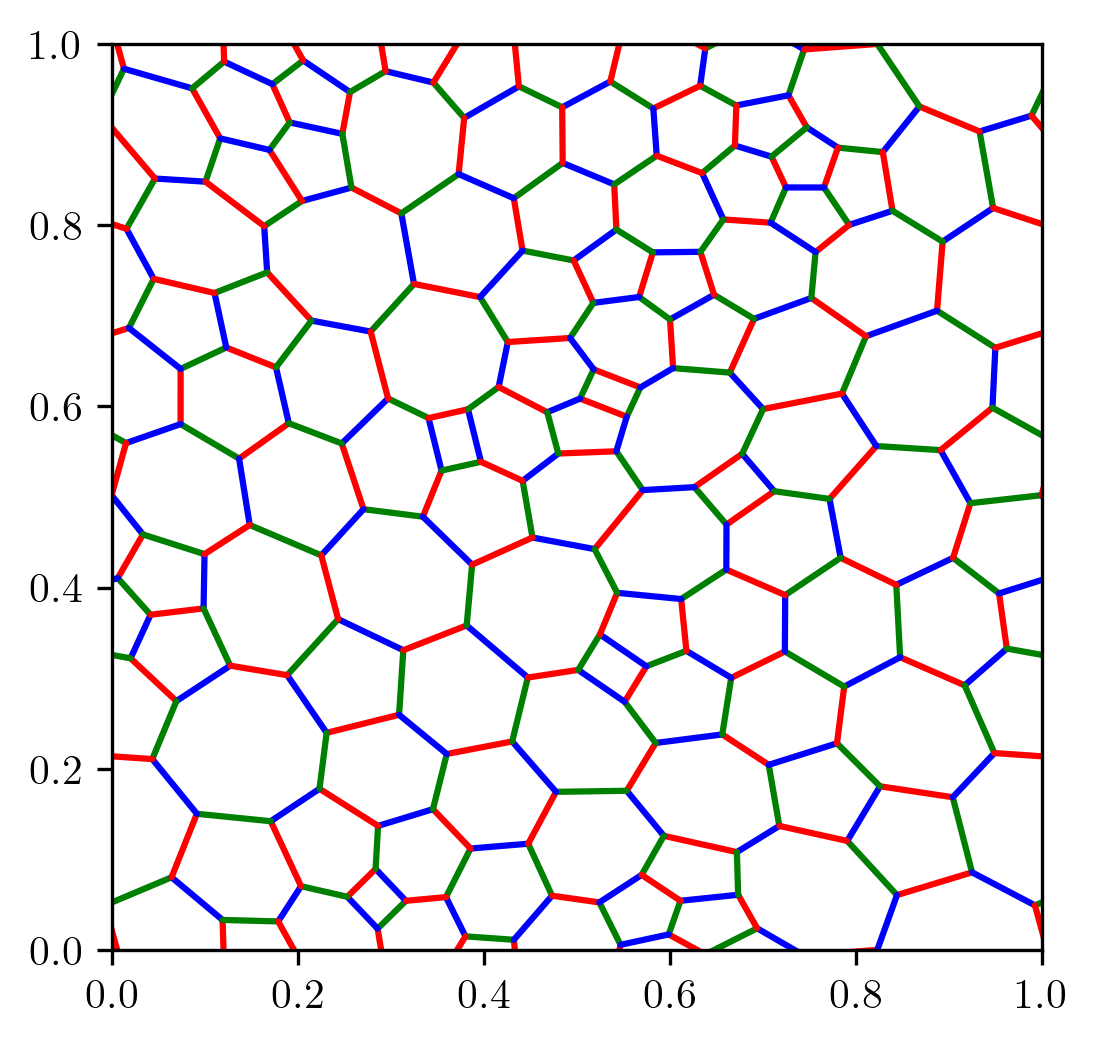

In [4]:

fig, ax = plt.subplots(figsize=(4, 4), dpi = 300)
pl.plot_edges(lattice, labels=coloring, color_scheme=['r','g','b'])


In [5]:
vals = np.linspace(0,1,200)

vals_x,vals_y = np.meshgrid(vals,vals)
xy = np.stack((vals_x,vals_y),axis=-1)


def worker_func(xy_in):
    x, y = xy_in
    if y>(1-x): return (np.nan, np.nan)
    J = generate_J(np.array([x,y]))
    # h = majorana_hamiltonian(lattice, coloring, ujk, J)
    # es = la.eigvalsh(h)
    # e = np.sum(np.abs(es))
    # g = np.min(np.abs(es))
    Hk = k_hamiltonian_generator(lattice, coloring,ujk,J)
    e, g = analyse_hk(Hk, 4)
    return (e, g)

xy_flattened = xy.reshape(-1,2)

with WorkerPool(n_jobs=8) as pool:
    results = pool.map(worker_func, [xy for xy in xy_flattened],progress_bar=True)
results = np.array(results).reshape(xy.shape)
e_vals = results[:,:,0]
g_vals = results[:,:,1]

  0%|          | 0/10000 [00:00<?, ?it/s]

In [6]:
e_vals = results[:,:,0]
g_vals = results[:,:,1]

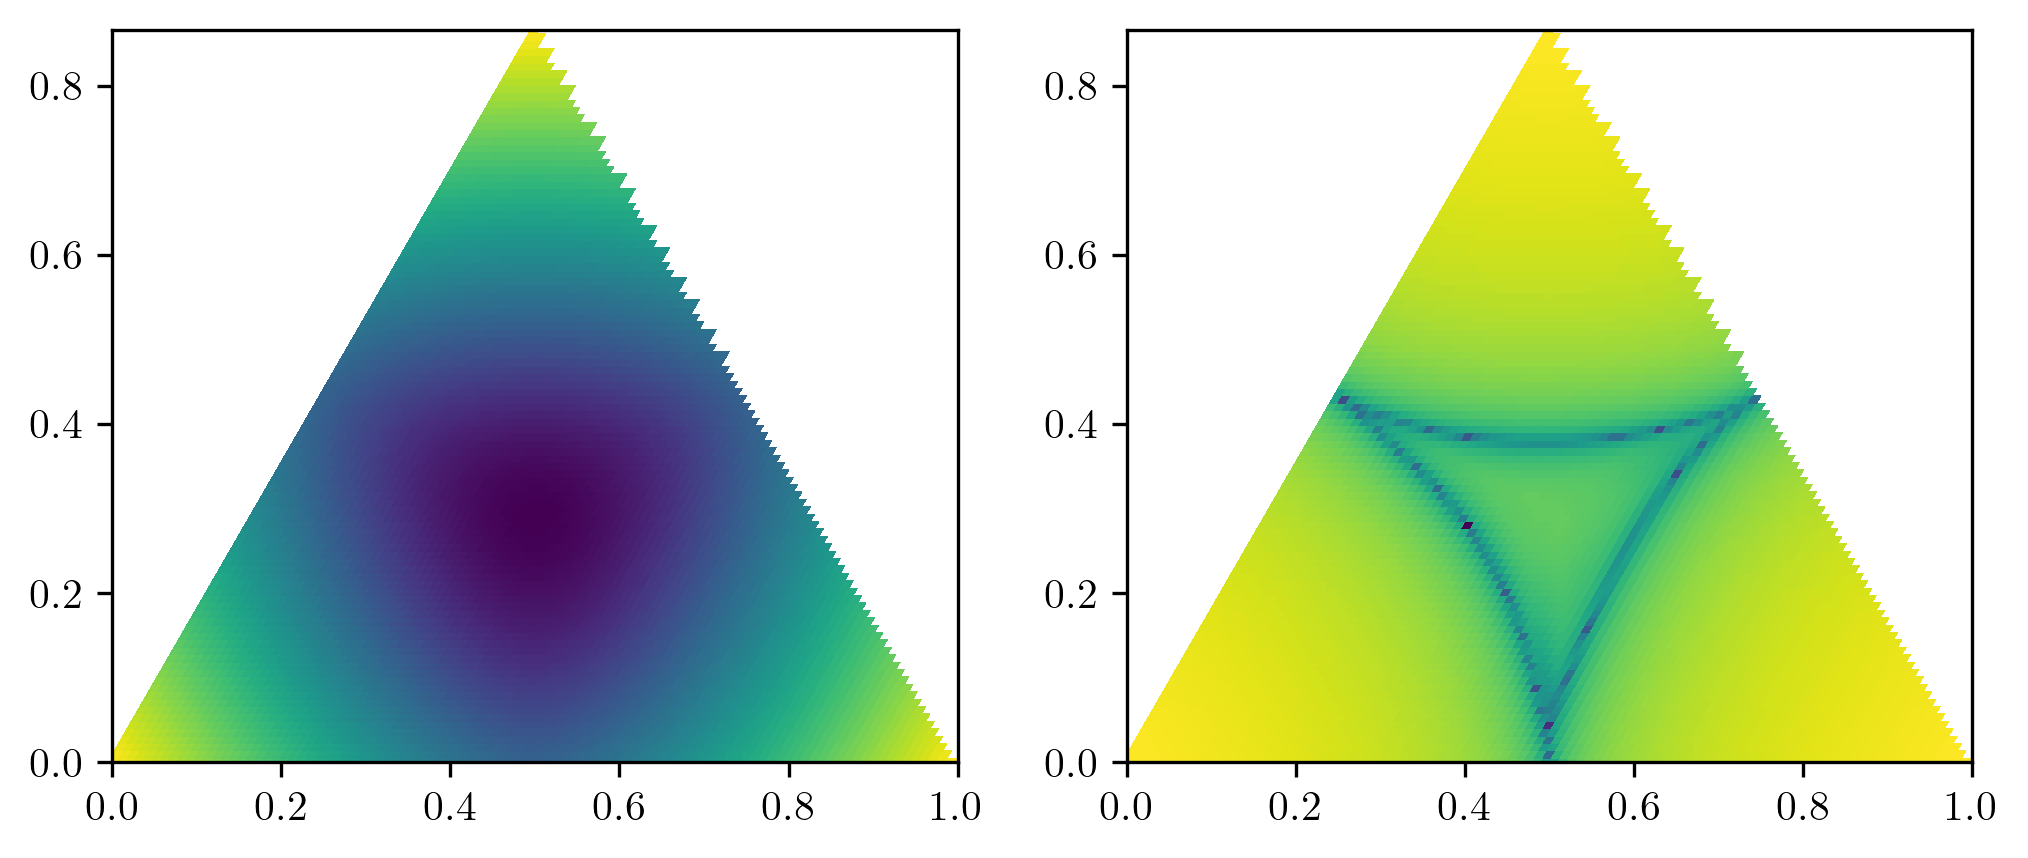

In [8]:
pos_x, pos_y = np.array(np.meshgrid(vals,vals))

x_vector = np.array([1,0])
y_vector = np.array([np.cos(np.pi/3),np.sin(np.pi/3)])

px = x_vector[0]*pos_x + y_vector[0]*pos_y
py = x_vector[1]*pos_x + y_vector[1]*pos_y

fig, ax = plt.subplots(1,2,figsize=(8, 4), dpi = 300)

for n, egvals in enumerate([e_vals, g_vals]):
    ax[n].pcolor(px, py,np.log(np.abs(egvals)))
    # fix aspect
    ax[n].set_aspect('equal', 'box')
    ax[n].set_xlim(0,1)
    ax[n].set_ylim(0,np.sin(np.pi/3))
plt.show()



In [5]:
fig, ax = plt.subplots(1,3,figsize=(12, 4), dpi = 300)
pl.plot_edges(lattice, labels=coloring, color_scheme=['k','k','w'], ax= ax[0])
pl.plot_edges(lattice, labels=coloring, color_scheme=['k','w','k'], ax= ax[1])
pl.plot_edges(lattice, labels=coloring, color_scheme=['w','k','k'], ax= ax[2])

NameError: name 'plt' is not defined